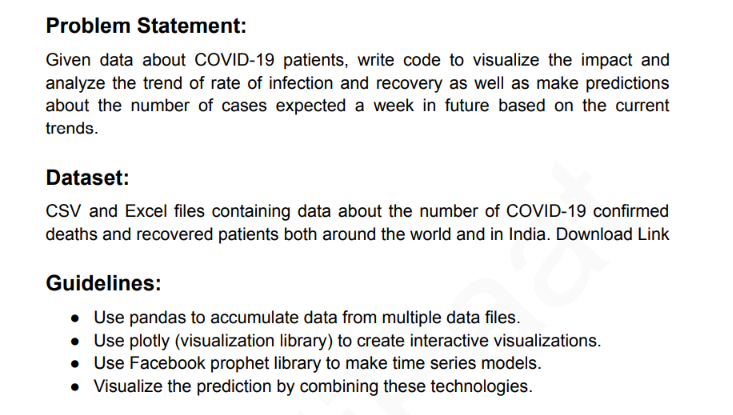

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, plotly as pl

In [2]:
df = pd.read_csv("covid_19_clean_complete.csv")
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [3]:
df.isnull().sum()

,0
Province/State,34404
Country/Region,0
Lat,0
Long,0
Date,0
Confirmed,0
Deaths,0
Recovered,0
Active,0
WHO Region,0


In [4]:
df['Province/State'].isnull().sum()
#Majority of the province data is null.

np.int64(34404)

In [5]:
df['Province/State']

,Province/State
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
49063,NaN
49064,NaN
49065,NaN
49066,NaN


In [6]:
df['Province/State'].unique()

array([nan, 'Australian Capital Territory', 'New South Wales',
       'Northern Territory', 'Queensland', 'South Australia', 'Tasmania',
       'Victoria', 'Western Australia', 'Alberta', 'British Columbia',
       'Manitoba', 'New Brunswick', 'Newfoundland and Labrador',
       'Nova Scotia', 'Ontario', 'Prince Edward Island', 'Quebec',
       'Saskatchewan', 'Anhui', 'Beijing', 'Chongqing', 'Fujian', 'Gansu',
       'Guangdong', 'Guangxi', 'Guizhou', 'Hainan', 'Hebei',
       'Heilongjiang', 'Henan', 'Hong Kong', 'Hubei', 'Hunan',
       'Inner Mongolia', 'Jiangsu', 'Jiangxi', 'Jilin', 'Liaoning',
       'Macau', 'Ningxia', 'Qinghai', 'Shaanxi', 'Shandong', 'Shanghai',
       'Shanxi', 'Sichuan', 'Tianjin', 'Tibet', 'Xinjiang', 'Yunnan',
       'Zhejiang', 'Faroe Islands', 'Greenland', 'French Guiana',
       'French Polynesia', 'Guadeloupe', 'Mayotte', 'New Caledonia',
       'Reunion', 'Saint Barthelemy', 'St Martin', 'Martinique', 'Aruba',
       'Curacao', 'Sint Maarten', 'Bermud

In [7]:
df.columns

Index(['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed',
       'Deaths', 'Recovered', 'Active', 'WHO Region'],
      dtype='object')

In [8]:
missing_values = ['', ' ', 'NA', 'N/A', 'na', 'null', 'NULL', 'None', 'Unknown', '-']

for value in missing_values:
    print(f"{repr(value)} :", (df == value).sum().sum())

'' : 0
' ' : 0
'NA' : 0
'N/A' : 0
'na' : 0
'null' : 0
'NULL' : 0
'None' : 0
'Unknown' : 0
'-' : 0



*  Total rows: 49,068
*  Province/State = NaN: 34,404

That's about 70% of the rows. Hence, we can drop this particular column.

In [9]:
df.drop('Province/State', inplace=True, errors='ignore')

In [10]:
df.columns

Index(['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed',
       'Deaths', 'Recovered', 'Active', 'WHO Region'],
      dtype='object')

In [11]:
df.drop(columns=['Province/State'], inplace=True)

In [12]:
df.head()

,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [13]:
print(df.dtypes)

Country/Region     object
Lat               float64
Long              float64
Date               object
Confirmed           int64
Deaths              int64
Recovered           int64
Active              int64
WHO Region         object
dtype: object


In [14]:
#Convert date to date dtype
df['Date'] = pd.to_datetime(df['Date'])

In [15]:
daily = df.groupby('Date')[['Confirmed', 'Deaths', 'Recovered']].sum().reset_index()

daily.head()

,Date,Confirmed,Deaths,Recovered
0,2020-01-22,555,17,28
1,2020-01-23,654,18,30
2,2020-01-24,941,26,36
3,2020-01-25,1434,42,39
4,2020-01-26,2118,56,52


In [16]:
daily['New Cases'] = daily['Confirmed'].diff()
daily['New Deaths'] = daily['Deaths'].diff()
daily['New Recovered'] = daily['Recovered'].diff()

In [17]:
daily.head()

,Date,Confirmed,Deaths,Recovered,New Cases,New Deaths,New Recovered
0,2020-01-22,555,17,28,NaN,NaN,NaN
1,2020-01-23,654,18,30,99.0,1.0,2.0
2,2020-01-24,941,26,36,287.0,8.0,6.0
3,2020-01-25,1434,42,39,493.0,16.0,3.0
4,2020-01-26,2118,56,52,684.0,14.0,13.0


In [18]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

## Prophet Model for Deaths

In [19]:
prophet_df_deaths = daily[['Date', 'Deaths']].copy()
prophet_df_deaths.columns = ['ds', 'y']

model_deaths = Prophet(weekly_seasonality=True, daily_seasonality=True) # Explicitly add seasonality
model_deaths.fit(prophet_df_deaths)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


In [20]:
future_deaths = model_deaths.make_future_dataframe(periods=30)
forecast_deaths = model_deaths.predict(future_deaths)
# Clip negative predictions to zero as deaths cannot be negative
forecast_deaths['yhat'] = forecast_deaths['yhat'].clip(lower=0)
forecast_deaths['yhat_lower'] = forecast_deaths['yhat_lower'].clip(lower=0)
forecast_deaths['yhat_upper'] = forecast_deaths['yhat_upper'].clip(lower=0)

In [21]:
import plotly.graph_objects as go

fig_deaths = go.Figure()

# Add actual deaths
fig_deaths.add_trace(go.Scatter(
    x=prophet_df_deaths['ds'],
    y=prophet_df_deaths['y'],
    mode='lines',
    name='Actual Deaths',
    line=dict(color='black')
))

# Add forecasted deaths
fig_deaths.add_trace(go.Scatter(
    x=forecast_deaths['ds'],
    y=forecast_deaths['yhat'],
    mode='lines',
    name='Forecasted Deaths',
    line=dict(color='blue')
))

# Add uncertainty interval
fig_deaths.add_trace(go.Scatter(
    x=forecast_deaths['ds'],
    y=forecast_deaths['yhat_lower'],
    mode='lines',
    line=dict(width=0),
    showlegend=False
))
fig_deaths.add_trace(go.Scatter(
    x=forecast_deaths['ds'],
    y=forecast_deaths['yhat_upper'],
    mode='lines',
    fill='tonexty',
    fillcolor='rgba(0,0,255,0.2)',
    line=dict(width=0),
    name='Uncertainty Interval',
    showlegend=True
))

fig_deaths.update_layout(
    title='Prophet Forecast for Deaths',
    xaxis_title='Date',
    yaxis_title='Deaths',
    hovermode='x unified'
)
fig_deaths.show()

In [22]:
actual_deaths = prophet_df_deaths['y']
predicted_deaths = forecast_deaths['yhat'].iloc[:len(prophet_df_deaths)]

mae_deaths = mean_absolute_error(actual_deaths, predicted_deaths)
rmse_deaths = np.sqrt(mean_squared_error(actual_deaths, predicted_deaths))

# Avoid division by zero for MAPE if actual_deaths contains zeros
# Using .abs() before replace to ensure positive values for scaling, if any zeros exist after smoothing
mape_deaths = np.mean(np.abs((actual_deaths - predicted_deaths) / actual_deaths.replace(0, np.nan).ffill())) * 100

print(f"Deaths - MAE: {mae_deaths:.2f}")
print(f"Deaths - RMSE: {rmse_deaths:.2f}")
print(f"Deaths - MAPE: {mape_deaths:.2f}%")

Deaths - MAE: 966.26
Deaths - RMSE: 1524.29
Deaths - MAPE: 33.04%


In [23]:
print('Upcoming Week (7 days) Forecast for Deaths:')
display(forecast_deaths[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(7))

print('\nUpcoming Month (30 days) Forecast for Deaths:')
display(forecast_deaths[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(30))

Upcoming Week (7 days) Forecast for Deaths:


,ds,yhat,yhat_lower,yhat_upper
211,2020-08-20,769094.468790,752923.589579,783330.283487
212,2020-08-21,774608.595763,756912.578255,790157.592811
213,2020-08-22,779492.876912,760861.267667,795524.009848
214,2020-08-23,783626.472626,763192.807118,801554.592110
215,2020-08-24,787916.792917,766394.320782,807118.474744
216,2020-08-25,793121.462003,771410.742324,812986.297976
217,2020-08-26,798688.177289,775339.470508,820229.341195



Upcoming Month (30 days) Forecast for Deaths:


,ds,yhat,yhat_lower,yhat_upper
188,2020-07-28,652310.605428,650376.474498,654316.395510
189,2020-07-29,657877.320714,655954.089929,659834.008016
190,2020-07-30,663486.326359,661354.605993,665598.348161
191,2020-07-31,669000.453331,666832.760608,671126.208948
192,2020-08-01,673884.734480,671577.395083,676226.839069
193,2020-08-02,678018.330194,675494.227870,680556.715096
194,2020-08-03,682308.650485,679524.551292,685170.358644
195,2020-08-04,687513.319571,684444.320135,690475.872599
196,2020-08-05,693080.034857,689705.006830,696710.854435
197,2020-08-06,698689.040502,694809.602147,702828.411075


In [24]:
future_deaths = model_deaths.make_future_dataframe(periods=30) # 7 days for week, 30 for month
forecast_deaths = model_deaths.predict(future_deaths)

In [25]:
import plotly.graph_objects as go

fig_deaths = go.Figure()

# Add actual deaths
fig_deaths.add_trace(go.Scatter(
    x=prophet_df_deaths['ds'],
    y=prophet_df_deaths['y'],
    mode='lines',
    name='Actual Deaths',
    line=dict(color='black')
))

# Add forecasted deaths
fig_deaths.add_trace(go.Scatter(
    x=forecast_deaths['ds'],
    y=forecast_deaths['yhat'],
    mode='lines',
    name='Forecasted Deaths',
    line=dict(color='blue')
))

# Add uncertainty interval
fig_deaths.add_trace(go.Scatter(
    x=forecast_deaths['ds'],
    y=forecast_deaths['yhat_lower'],
    mode='lines',
    line=dict(width=0),
    showlegend=False
))
fig_deaths.add_trace(go.Scatter(
    x=forecast_deaths['ds'],
    y=forecast_deaths['yhat_upper'],
    mode='lines',
    fill='tonexty',
    fillcolor='rgba(0,0,255,0.2)',
    line=dict(width=0),
    name='Uncertainty Interval',
    showlegend=True
))

fig_deaths.update_layout(
    title='Prophet Forecast for Deaths',
    xaxis_title='Date',
    yaxis_title='Deaths',
    hovermode='x unified'
)
fig_deaths.show()

### Accuracy Metrics for Deaths

In [37]:
actual_deaths_7_days = prophet_df_deaths['y'].tail(7)
predicted_deaths_7_days = forecast_deaths['yhat'].iloc[len(prophet_df_deaths)-7 : len(prophet_df_deaths)]

mae_deaths = mean_absolute_error(actual_deaths_7_days, predicted_deaths_7_days)
rmse_deaths = np.sqrt(mean_squared_error(actual_deaths_7_days, predicted_deaths_7_days))

# Avoid division by zero for MAPE if actual_deaths contains zeros
mape_deaths = np.mean(np.abs((actual_deaths_7_days - predicted_deaths_7_days) / actual_deaths_7_days.replace(0, np.nan).ffill())) * 100

print(f"Deaths (last 7 days) - MAE: {mae_deaths:.2f}")
print(f"Deaths (last 7 days) - RMSE: {rmse_deaths:.2f}")
print(f"Deaths (last 7 days) - MAPE: {mape_deaths:.2f}%")

Deaths (last 7 days) - MAE: 4437.34
Deaths (last 7 days) - RMSE: 5047.63
Deaths (last 7 days) - MAPE: 0.69%


## Prophet Model for Recovered Cases

In [27]:
prophet_df_recovered = daily[['Date', 'Recovered']].copy()
prophet_df_recovered.columns = ['ds', 'y']

model_recovered = Prophet(weekly_seasonality=True, daily_seasonality=True) # Explicitly add seasonality
model_recovered.fit(prophet_df_recovered)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


In [28]:
future_recovered = model_recovered.make_future_dataframe(periods=30)
forecast_recovered = model_recovered.predict(future_recovered)
# Clip negative predictions to zero as recovered cases cannot be negative
forecast_recovered['yhat'] = forecast_recovered['yhat'].clip(lower=0)
forecast_recovered['yhat_lower'] = forecast_recovered['yhat_lower'].clip(lower=0)
forecast_recovered['yhat_upper'] = forecast_recovered['yhat_upper'].clip(lower=0)

In [29]:
import plotly.graph_objects as go

fig_recovered = go.Figure()

# Add actual recovered
fig_recovered.add_trace(go.Scatter(
    x=prophet_df_recovered['ds'],
    y=prophet_df_recovered['y'],
    mode='lines',
    name='Actual Recovered',
    line=dict(color='black')
))

# Add forecasted recovered
fig_recovered.add_trace(go.Scatter(
    x=forecast_recovered['ds'],
    y=forecast_recovered['yhat'],
    mode='lines',
    name='Forecasted Recovered',
    line=dict(color='green')
))

# Add uncertainty interval
fig_recovered.add_trace(go.Scatter(
    x=forecast_recovered['ds'],
    y=forecast_recovered['yhat_lower'],
    mode='lines',
    line=dict(width=0),
    showlegend=False
))
fig_recovered.add_trace(go.Scatter(
    x=forecast_recovered['ds'],
    y=forecast_recovered['yhat_upper'],
    mode='lines',
    fill='tonexty',
    fillcolor='rgba(0,255,0,0.2)',
    line=dict(width=0),
    name='Uncertainty Interval',
    showlegend=True
))

fig_recovered.update_layout(
    title='Prophet Forecast for Recovered Cases',
    xaxis_title='Date',
    yaxis_title='Recovered Cases',
    hovermode='x unified'
)
fig_recovered.show()

In [30]:
actual_recovered = prophet_df_recovered['y']
predicted_recovered = forecast_recovered['yhat'].iloc[:len(prophet_df_recovered)]

mae_recovered = mean_absolute_error(actual_recovered, predicted_recovered)
rmse_recovered = np.sqrt(mean_squared_error(actual_recovered, predicted_recovered))

# Avoid division by zero for MAPE if actual_recovered contains zeros
# Using .abs() before replace to ensure positive values for scaling, if any zeros exist after smoothing
mape_recovered = np.mean(np.abs((actual_recovered - predicted_recovered) / actual_recovered.replace(0, np.nan).ffill())) * 100

print(f"Recovered - MAE: {mae_recovered:.2f}")
print(f"Recovered - RMSE: {rmse_recovered:.2f}")
print(f"Recovered - MAPE: {mape_recovered:.2f}%")

Recovered - MAE: 31179.77
Recovered - RMSE: 61109.06
Recovered - MAPE: 43.15%


In [31]:
print('Upcoming Week (7 days) Forecast for Recovered Cases:')
display(forecast_recovered[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(7))

print('\nUpcoming Month (30 days) Forecast for Recovered Cases:')
display(forecast_recovered[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(30))

Upcoming Week (7 days) Forecast for Recovered Cases:


,ds,yhat,yhat_lower,yhat_upper
211,2020-08-20,1.247093e+07,1.224502e+07,1.269183e+07
212,2020-08-21,1.261250e+07,1.237762e+07,1.285177e+07
213,2020-08-22,1.275284e+07,1.250118e+07,1.301677e+07
214,2020-08-23,1.287898e+07,1.261904e+07,1.315109e+07
215,2020-08-24,1.301555e+07,1.272382e+07,1.330263e+07
216,2020-08-25,1.314291e+07,1.283719e+07,1.344532e+07
217,2020-08-26,1.328529e+07,1.296443e+07,1.361904e+07



Upcoming Month (30 days) Forecast for Recovered Cases:


,ds,yhat,yhat_lower,yhat_upper
188,2020-07-28,9.314111e+06,9.234349e+06,9.391594e+06
189,2020-07-29,9.456488e+06,9.377418e+06,9.537456e+06
190,2020-07-30,9.599332e+06,9.520554e+06,9.677905e+06
191,2020-07-31,9.740897e+06,9.662000e+06,9.814937e+06
192,2020-08-01,9.881242e+06,9.800721e+06,9.971428e+06
193,2020-08-02,1.000738e+07,9.926407e+06,1.009001e+07
194,2020-08-03,1.014395e+07,1.005139e+07,1.022820e+07
195,2020-08-04,1.027131e+07,1.018316e+07,1.035880e+07
196,2020-08-05,1.041369e+07,1.032034e+07,1.050796e+07
197,2020-08-06,1.055653e+07,1.045795e+07,1.065434e+07


### Normalized Forecasted Recovered Cases

In [32]:
# Normalize yhat, yhat_lower, yhat_upper by the maximum yhat value to show relative proportion
max_yhat_recovered = forecast_recovered['yhat'].max()

forecast_recovered['yhat_normalized'] = forecast_recovered['yhat'] / max_yhat_recovered
forecast_recovered['yhat_lower_normalized'] = forecast_recovered['yhat_lower'] / max_yhat_recovered
forecast_recovered['yhat_upper_normalized'] = forecast_recovered['yhat_upper'] / max_yhat_recovered

print('Normalized Forecast for Recovered Cases:')
display(forecast_recovered[['ds', 'yhat_normalized', 'yhat_lower_normalized', 'yhat_upper_normalized']].tail(7))
print("\n*   'yhat_normalized': The forecasted daily recovered cases as a proportion of the maximum forecasted daily recovered cases.")
print("*   'yhat_lower_normalized': The lower bound of the 80% confidence interval for daily recovered cases, normalized by the maximum forecasted daily recovered cases.")
print("*   'yhat_upper_normalized': The upper bound of the 80% confidence interval for daily recovered cases, normalized by the maximum forecasted daily recovered cases.")

Normalized Forecast for Recovered Cases:


,ds,yhat_normalized,yhat_lower_normalized,yhat_upper_normalized
211,2020-08-20,0.938702,0.921698,0.955330
212,2020-08-21,0.949358,0.931679,0.967368
213,2020-08-22,0.959922,0.940979,0.979788
214,2020-08-23,0.969417,0.949851,0.989899
215,2020-08-24,0.979697,0.957738,1.001306
216,2020-08-25,0.989283,0.966272,1.012046
217,2020-08-26,1.000000,0.975849,1.025122



*   'yhat_normalized': The forecasted daily recovered cases as a proportion of the maximum forecasted daily recovered cases.
*   'yhat_lower_normalized': The lower bound of the 80% confidence interval for daily recovered cases, normalized by the maximum forecasted daily recovered cases.
*   'yhat_upper_normalized': The upper bound of the 80% confidence interval for daily recovered cases, normalized by the maximum forecasted daily recovered cases.


### Normalized Forecasted Recovered Cases

In [33]:
# Normalize yhat, yhat_lower, yhat_upper by the maximum yhat value to show relative proportion
max_yhat_recovered = forecast_recovered['yhat'].max()

forecast_recovered['yhat_normalized'] = forecast_recovered['yhat'] / max_yhat_recovered
forecast_recovered['yhat_lower_normalized'] = forecast_recovered['yhat_lower'] / max_yhat_recovered
forecast_recovered['yhat_upper_normalized'] = forecast_recovered['yhat_upper'] / max_yhat_recovered

print('Normalized Forecast for Recovered Cases:')
display(forecast_recovered[['ds', 'yhat_normalized', 'yhat_lower_normalized', 'yhat_upper_normalized']].tail(7))
print("\n*   'yhat_normalized': The forecasted daily recovered cases as a proportion of the maximum forecasted daily recovered cases.")
print("*   'yhat_lower_normalized': The lower bound of the 80% confidence interval for daily recovered cases, normalized by the maximum forecasted daily recovered cases.")
print("*   'yhat_upper_normalized': The upper bound of the 80% confidence interval for daily recovered cases, normalized by the maximum forecasted daily recovered cases.")

Normalized Forecast for Recovered Cases:


,ds,yhat_normalized,yhat_lower_normalized,yhat_upper_normalized
211,2020-08-20,0.938702,0.921698,0.955330
212,2020-08-21,0.949358,0.931679,0.967368
213,2020-08-22,0.959922,0.940979,0.979788
214,2020-08-23,0.969417,0.949851,0.989899
215,2020-08-24,0.979697,0.957738,1.001306
216,2020-08-25,0.989283,0.966272,1.012046
217,2020-08-26,1.000000,0.975849,1.025122



*   'yhat_normalized': The forecasted daily recovered cases as a proportion of the maximum forecasted daily recovered cases.
*   'yhat_lower_normalized': The lower bound of the 80% confidence interval for daily recovered cases, normalized by the maximum forecasted daily recovered cases.
*   'yhat_upper_normalized': The upper bound of the 80% confidence interval for daily recovered cases, normalized by the maximum forecasted daily recovered cases.


In [34]:
future_recovered = model_recovered.make_future_dataframe(periods=30) # 7 days for week, 30 for month
forecast_recovered = model_recovered.predict(future_recovered)

In [35]:
import plotly.graph_objects as go

fig_recovered = go.Figure()

# Add actual recovered
fig_recovered.add_trace(go.Scatter(
    x=prophet_df_recovered['ds'],
    y=prophet_df_recovered['y'],
    mode='lines',
    name='Actual Recovered',
    line=dict(color='black')
))

# Add forecasted recovered
fig_recovered.add_trace(go.Scatter(
    x=forecast_recovered['ds'],
    y=forecast_recovered['yhat'],
    mode='lines',
    name='Forecasted Recovered',
    line=dict(color='green')
))

# Add uncertainty interval
fig_recovered.add_trace(go.Scatter(
    x=forecast_recovered['ds'],
    y=forecast_recovered['yhat_lower'],
    mode='lines',
    line=dict(width=0),
    showlegend=False
))
fig_recovered.add_trace(go.Scatter(
    x=forecast_recovered['ds'],
    y=forecast_recovered['yhat_upper'],
    mode='lines',
    fill='tonexty',
    fillcolor='rgba(0,255,0,0.2)',
    line=dict(width=0),
    name='Uncertainty Interval',
    showlegend=True
))

fig_recovered.update_layout(
    title='Prophet Forecast for Recovered Cases',
    xaxis_title='Date',
    yaxis_title='Recovered Cases',
    hovermode='x unified'
)
fig_recovered.show()

### Accuracy Metrics for Recovered Cases

In [38]:
actual_recovered_7_days = prophet_df_recovered['y'].tail(7)
predicted_recovered_7_days = forecast_recovered['yhat'].iloc[len(prophet_df_recovered)-7 : len(prophet_df_recovered)]

mae_recovered = mean_absolute_error(actual_recovered_7_days, predicted_recovered_7_days)
rmse_recovered = np.sqrt(mean_squared_error(actual_recovered_7_days, predicted_recovered_7_days))

# Avoid division by zero for MAPE if actual_recovered contains zeros
mape_recovered = np.mean(np.abs((actual_recovered_7_days - predicted_recovered_7_days) / actual_recovered_7_days.replace(0, np.nan).ffill())) * 100

print(f"Recovered (last 7 days) - MAE: {mae_recovered:.2f}")
print(f"Recovered (last 7 days) - RMSE: {rmse_recovered:.2f}")
print(f"Recovered (last 7 days) - MAPE: {mape_recovered:.2f}%")

Recovered (last 7 days) - MAE: 147742.90
Recovered (last 7 days) - RMSE: 179013.76
Recovered (last 7 days) - MAPE: 1.61%
